
### Project 02: Student Performance Analysis

Objective:
Analyze student performance data to identify factors affecting grades, detect at-risk students, and provide actionable recommendations for improving academic outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/project 2 students/StudentsPerformance (1).csv')

###Basic Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.shape

(1000, 8)

In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


###Null Values

In [8]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


###Duplicate Values

In [9]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

### Dataset Summary

1. Dataset contains student academic performance records.
2. Includes demographic and educational factors.
3. Contains math, reading and writing scores.
4. No missing values were found.
5. Dataset is useful for identifying factors affecting performance.

###Create Total Score

In [10]:
df["total_score"] = (
    df["math score"]
    + df["reading score"]
    + df["writing score"]
)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


###FACTOR ANALYSIS QUESTION 1
Does parental education affect scores?

In [11]:
parent_scores = df.groupby(
    "parental level of education"
)[["math score","reading score","writing score"]].mean()

parent_scores

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


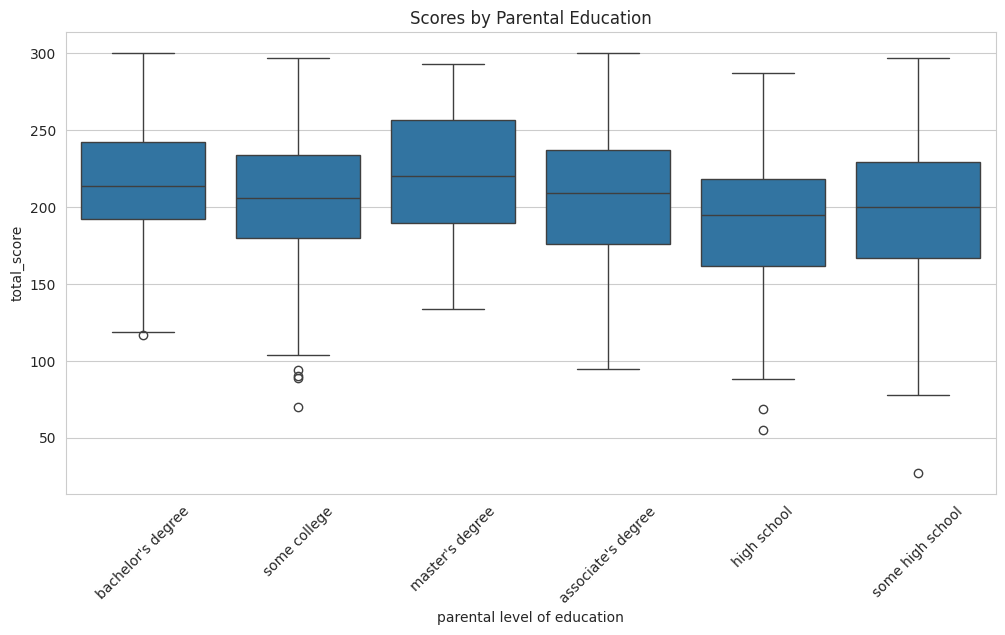

In [12]:
#Box Plot
plt.figure(figsize=(12,6))

sns.boxplot(
    x="parental level of education",
    y="total_score",
    data=df
)

plt.title("Scores by Parental Education")
plt.xticks(rotation=45)
plt.show()

### Insight 1

Students whose parents have higher educational qualifications generally achieve better academic scores.

###FACTOR ANALYSIS QUESTION 2
Do students who complete test preparation score higher?

In [13]:
prep = df.groupby(
    "test preparation course"
)["total_score"].mean()

prep

,total_score
test preparation course,
completed,218.008380
none,195.116822


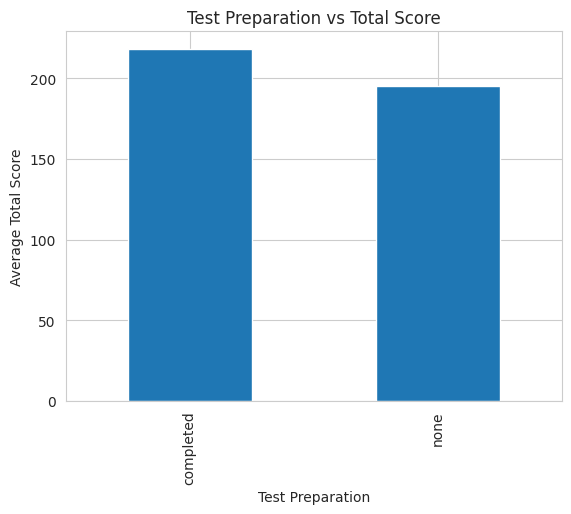

In [14]:
prep.plot(kind="bar")

plt.title("Test Preparation vs Total Score")
plt.xlabel("Test Preparation")
plt.ylabel("Average Total Score")

plt.show()

### Insight 2

Students who completed the test preparation course scored higher in all three subjects compared to those who did not.

###FACTOR ANALYSIS QUESTION 3
 What Is The Correlation Between Reading, Writing And Math Scores?

In [15]:
corr_matrix = df[
    ["math score","reading score","writing score"]
].corr()

corr_matrix

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


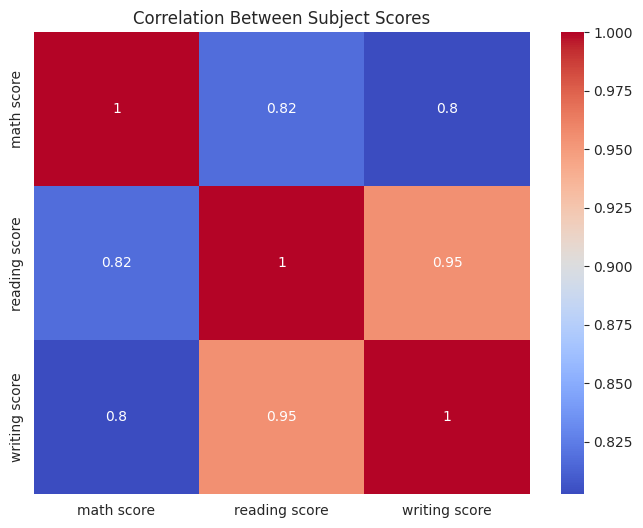

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Subject Scores")

plt.show()

### Insight 3

Reading and writing scores usually show the strongest positive correlation. Students performing well in one subject often perform well in others.

###FACTOR ANALYSIS QUESTION 4
Which Gender Performs Better In Which Subject?

In [17]:
gender_scores = df.groupby(
    "gender"
)[["math score","reading score","writing score"]].mean()

gender_scores

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


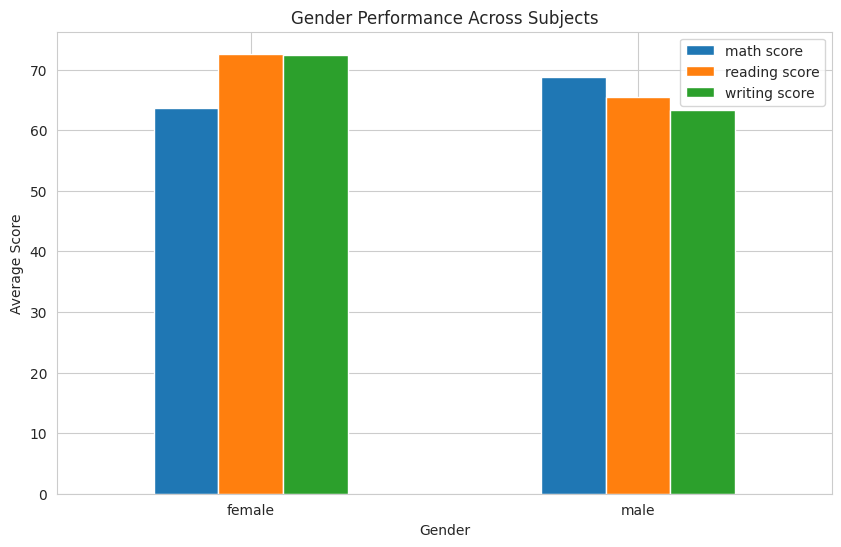

In [18]:
gender_scores.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Gender Performance Across Subjects")
plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.show()

### Insight 4

Male students generally perform better in Mathematics, while female students often score higher in Reading and Writing.

###FACTOR ANALYSIS QUESTION 5
What Is The Distribution Of Total Scores?

In [19]:
df["total_score"].describe()

,total_score
count,1000.000000
mean,203.312000
std,42.771978
min,27.000000
25%,175.000000
50%,205.000000
75%,233.000000
max,300.000000


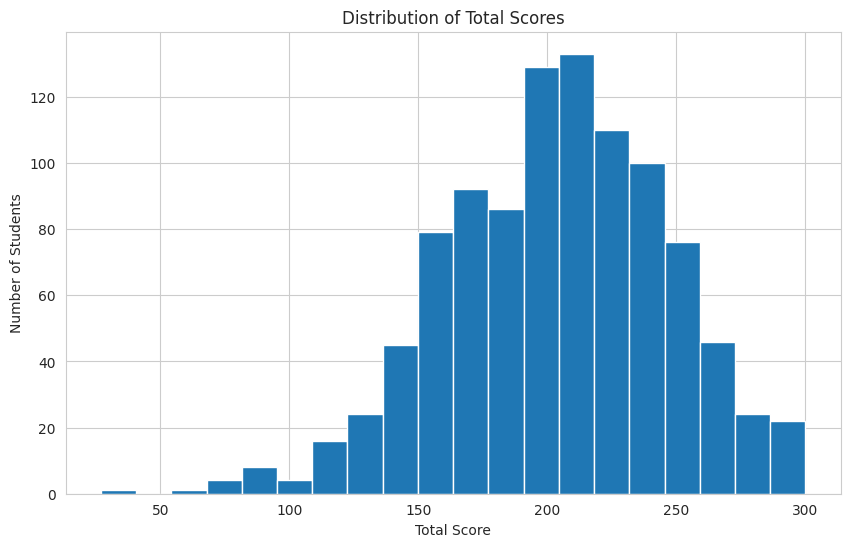

In [20]:
plt.figure(figsize=(10,6))

plt.hist(
    df["total_score"],
    bins=20
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

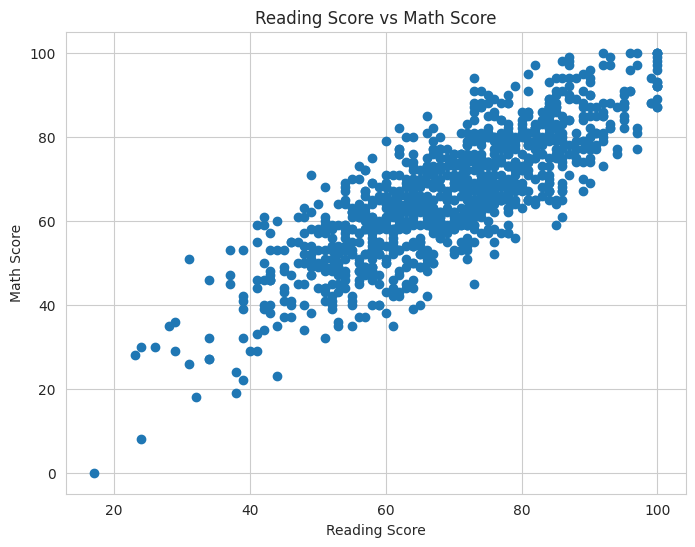

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["reading score"],
    df["math score"]
)

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.show()

### Insight 5

Most students score within the middle range, while fewer students achieve extremely high or extremely low total scores.

###AT-RISK STUDENT SEGMENTATION

In [22]:
df["at_risk"] = (
    (df["math score"] < 50)
    |
    (df["reading score"] < 50)
    |
    (df["writing score"] < 50)
)

In [23]:
df["at_risk"].value_counts()

,count
at_risk,
False,812
True,188


In [24]:
at_risk_count = df["at_risk"].sum()

print("At Risk Students:", at_risk_count)

At Risk Students: 188


In [25]:
risk_group = pd.crosstab(
    df["parental level of education"],
    df["at_risk"],
    normalize="index"
)*100

risk_group

at_risk,False,True
parental level of education,,
associate's degree,85.135135,14.864865
bachelor's degree,86.440678,13.559322
high school,75.000000,25.000000
master's degree,89.830508,10.169492
some college,83.185841,16.814159
some high school,74.301676,25.698324


###Principal's Report

Executive Summary

The student performance dataset was analyzed to understand the factors affecting academic results. Different factors such as parental education level, test preparation, and gender were examined. The analysis also identified students who may need additional academic support.

##Key Findings
1.Students who completed the test preparation course generally scored higher than students who did not complete it.

2.Reading and writing scores were strongly related, meaning students who performed well in reading usually performed well in writing too.

3.Students whose parents had higher education levels tended to achieve better overall scores.

4.Female students performed better in reading and writing, while male students showed slightly better performance in mathematics.

5.A considerable number of students scored below the expected level in at least one subject and were classified as at-risk students.



##Recommendations
1.Encourage more students to participate in test preparation programs before examinations.

2.Provide extra support classes for students identified as at-risk, especially in subjects where they scored below average.

3.Organize parent awareness sessions to help families support their children's learning at home.

#### Most Impactful Recommendation

The recommendation I found most impactful is increasing participation in test preparation programs. The analysis showed that students who completed the preparation course consistently achieved higher scores across all subjects. Expanding these programs can help improve overall academic performance and reduce the number of at-risk students.


### Conclusion

This project analyzed student performance data to identify the factors influencing academic achievement. The results showed that parental education, test preparation, and student demographics have a noticeable impact on scores. The analysis also helped identify at-risk students and provided recommendations that can support improved academic outcomes.